<a href="https://colab.research.google.com/github/RuiRodrigues-lab/DataScienceFE/blob/Locker/CP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
#Precisamos desta biblioteca para podermos escolher um ficheiro local
#Se o ficheiro vier por API ou tivermos um link, é so alterar a forma de import
from google.colab import files

# 1️⃣ Faz upload do ficheiro (vai abrir uma janela para escolher no teu PC)
uploaded = files.upload()

# 2️⃣ Guarda o nome do ficheiro (Colab mostra o nome depois do upload)
filename = list(uploaded.keys())[0]

# 3️⃣ Lê o Excel, por default lê sempre a primeira tab, por isso podemos usar o "sheet_name"
# Se tivermos dados em varias tabs, devemos usar uma Dataframe(df) para cada uma das tabs
df = pd.read_excel(filename, sheet_name='Dados')
df.head()

Saving CP2.xlsx to CP2 (1).xlsx


,Idade,Sexo,Residencia,Cohabitação,Deslocação,HorasEstudo,Altura,Peso,Cinema,SatisfaçãoLic
0,20,Masculino,Setúbal,Pais,10,3.0,178,83,Ficção Científica,Satisfeito
1,21,Feminino,Setúbal,Colegas,30,8.0,170,65,Comédia,Muito Satisfeito
2,20,Feminino,Setúbal,Colegas,15,6.0,165,55,Comédia,Satisfeito
3,21,Feminino,Setúbal,Colegas,45,12.0,170,55,Ficção Científica,Pouco Satisfeito
4,20,Feminino,Setúbal,Colegas,25,3.0,150,46,Comédia,Satisfeito


In [ ]:
#A função df.shape devolve o numero de linhas e colunas do Dataframe(df)
linhas, colunas = df.shape
print("Número de linhas:", linhas)
print("Número de colunas:", colunas)

#Tambem temos a função df.describe que é muito gira mas os resultados podem ser um pouco confusos:
#df.describe()
#Por isso devemos apontar as colunas em que este valores fazem sentido usando ela assim:
#print("\nMedidas Estatísticas Descritivas:")
#print("\nAmplitude Inter Quartis (AIQ): Q0,75-Q0,25")
#print("\nRange: Max - Min")
df[['Idade', 'Altura', 'Peso', 'HorasEstudo']].describe()



Número de linhas: 33
Número de colunas: 10


,Idade,Altura,Peso,HorasEstudo
count,33.000000,33.000000,33.000000,33.000000
mean,21.030303,167.545455,65.181818,7.712121
std,1.590693,8.771726,11.484921,5.455832
min,20.000000,150.000000,46.000000,1.000000
25%,20.000000,161.000000,58.000000,4.000000
50%,21.000000,165.000000,64.000000,7.000000
75%,21.000000,174.000000,68.000000,9.500000
max,28.000000,185.000000,96.000000,28.000000


In [ ]:
#Tambem temos esta forma de calcular o anterior, com esta sintaxe podemos ter o "skew" e o kurtosis
num_cols = ['Idade', 'Altura', 'Peso', 'HorasEstudo']

# Estatísticas principais
desc = df[num_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max', 'skew', 'kurtosis']).T

# Quartis (Q1, Q3) + Range
desc['Q1'] = df[num_cols].quantile(0.25)
desc['Q2'] = df[num_cols].quantile(0.50)  # mediana, só para consistência
desc['Q3'] = df[num_cols].quantile(0.75)
desc['Range'] = desc['max'] - desc['min']

# Arredondar e reordenar colunas
desc = desc[['count', 'mean', 'std', 'min', 'Q1', 'Q2', 'Q3', 'max', 'Range', 'skew', 'kurtosis']].round(3)

desc

#skewness() calcula a assimetria da distribuição:
#•	0 → simétrica,
#•	positiva → cauda à direita,
#•	negativa → cauda à esquerda.
#Curtose mede o grau de concentração dos valores em torno da média — distribuições com curtose alta têm caudas mais pesadas (mais valores extremos) e as de curtose baixa são mais achatadas.

,count,mean,std,min,Q1,Q2,Q3,max,Range,skew,kurtosis
Idade,33.0,21.030,1.591,20.0,20.0,21.0,21.0,28.0,8.0,3.022,11.326
Altura,33.0,167.545,8.772,150.0,161.0,165.0,174.0,185.0,35.0,0.216,-0.599
Peso,33.0,65.182,11.485,46.0,58.0,64.0,68.0,96.0,50.0,1.269,1.716
HorasEstudo,33.0,7.712,5.456,1.0,4.0,7.0,9.5,28.0,27.0,1.975,5.392


In [ ]:
#Mostra os tipos de variaveis e estrutura do data set
#Dtype = object = string
#Dtype = category = definimos as classes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Idade          33 non-null     int64  
 1   Sexo           33 non-null     object 
 2   Residencia     33 non-null     object 
 3   Cohabitação    33 non-null     object 
 4   Deslocação     33 non-null     int64  
 5   HorasEstudo    33 non-null     float64
 6   Altura         33 non-null     int64  
 7   Peso           33 non-null     int64  
 8   Cinema         33 non-null     object 
 9   SatisfaçãoLic  33 non-null     object 
dtypes: float64(1), int64(4), object(5)
memory usage: 2.7+ KB


In [ ]:
# 🔹 Variáveis nominais: Sexo, Residência, Cinema
cols_nominais = ['Sexo', 'Residencia', 'Cinema']
df[cols_nominais] = df[cols_nominais].astype('category')

# 🔹 Variável ordinal: Cohabitação (ordem definida manualmente)
cohabit_levels = ['Pais', 'Outros familiares', 'Colegas', 'Sozinho/a']
cohabit_type = CategoricalDtype(categories=cohabit_levels, ordered=True)
df['Cohabitação'] = df['Cohabitação'].astype(cohabit_type)

# 🔹 Variável ordinal: SatisfaçãoLic, se quiseres já definir a ordem
satisf_levels = ['Insatisfeito', 'Pouco Satisfeito', 'Satisfeito', 'Muito Satisfeito']
satisf_type = CategoricalDtype(categories=satisf_levels, ordered=True)
df['SatisfaçãoLic'] = df['SatisfaçãoLic'].astype(satisf_type)

#Para vermos se ficou tudo bem, definimos esta função
def glimpse(df):
    print(f"📊 DataFrame com {df.shape[0]} linhas e {df.shape[1]} colunas\n")
    for col in df.columns:
        dtype = df[col].dtype
        preview = df[col].unique()[:5]  # mostra até 5 valores únicos
        print(f"{col:<15} ({dtype})  →  {preview}")

#print
glimpse(df)

📊 DataFrame com 33 linhas e 10 colunas

Idade           (int64)  →  [20 21 22 24 23]
Sexo            (category)  →  ['Masculino', 'Feminino']
Categories (2, object): ['Feminino', 'Masculino']
Residencia      (category)  →  ['Setúbal', 'Seixal', 'Palmela']
Categories (3, object): ['Palmela', 'Seixal', 'Setúbal']
Cohabitação     (category)  →  ['Pais', 'Colegas', 'Outros familiares', 'Sozinho/a']
Categories (4, object): ['Pais' < 'Outros familiares' < 'Colegas' < 'Sozinho/a']
Deslocação      (int64)  →  [10 30 15 45 25]
HorasEstudo     (float64)  →  [ 3.  8.  6. 12.  4.]
Altura          (int64)  →  [178 170 165 150 161]
Peso            (int64)  →  [83 65 55 46 52]
Cinema          (category)  →  ['Ficção Científica', 'Comédia', 'Aventura', 'Ação', 'Terror']
Categories (5, object): ['Aventura', 'Ação', 'Comédia', 'Ficção Científica', 'Terror']
SatisfaçãoLic   (category)  →  ['Satisfeito', 'Muito Satisfeito', 'Pouco Satisfeito', 'Insatisfeito']
Categories (4, object): ['Insatisfeito' < 'Pou

In [ ]:
#Tabela Sexo
freq_abs = df["Sexo"].value_counts() #Frequencias Absolutas
freq_rel = df["Sexo"].value_counts(normalize=True).round(4)*100 #Frequencias Relativas
#Aqui juntamos ambas as columas que calculamos antes em uma tabela
tabelaSexo = pd.DataFrame({
    "Frequência": freq_abs,
    "Frequência Relativa(%)": freq_rel
})

#Tabela Residencia
freq_abs = df["Residencia"].value_counts()
freq_rel = df["Residencia"].value_counts(normalize=True).round(2)
tabelaResidencia = pd.DataFrame({
    "Frequência": freq_abs,
    "Frequência Relativa": freq_rel
})

#Tabela Cohabitação
freq_abs = df["Cohabitação"].value_counts()
freq_rel = df["Cohabitação"].value_counts(normalize=True).round(2)
tabelaCohabitação = pd.DataFrame({
    "Frequência": freq_abs,
    "Frequência Relativa": freq_rel
})

#Tabela Cinema
freq_abs = df["Cinema"].value_counts()
freq_rel = df["Cinema"].value_counts(normalize=True).round(2)
tabelaCinema = pd.DataFrame({
    "Frequência": freq_abs,
    "Frequência Relativa": freq_rel
})

#Tabela SatisfaçãoLic
freq_abs = df["SatisfaçãoLic"].value_counts()
freq_rel = df["SatisfaçãoLic"].value_counts(normalize=True).round(2)
tabelaSatisfaçãoLic = pd.DataFrame({
    "Frequência": freq_abs,
    "Frequência Relativa": freq_rel
})

tabelaSexo


,Frequência,Frequência Relativa(%)
Sexo,,
Feminino,22,66.67
Masculino,11,33.33


In [ ]:
tabelaResidencia


,Frequência,Frequência Relativa
Residencia,,
Setúbal,12,0.36
Seixal,11,0.33
Palmela,10,0.30


In [ ]:
tabelaCohabitação


,Frequência,Frequência Relativa
Cohabitação,,
Pais,19,0.58
Colegas,11,0.33
Sozinho/a,2,0.06
Outros familiares,1,0.03


In [ ]:
tabelaCinema

,Frequência,Frequência Relativa
Cinema,,
Comédia,19,0.58
Aventura,5,0.15
Ação,4,0.12
Ficção Científica,4,0.12
Terror,1,0.03


In [ ]:
tabelaSatisfaçãoLic

,Frequência,Frequência Relativa
SatisfaçãoLic,,
Satisfeito,19,0.58
Muito Satisfeito,9,0.27
Pouco Satisfeito,3,0.09
Insatisfeito,2,0.06


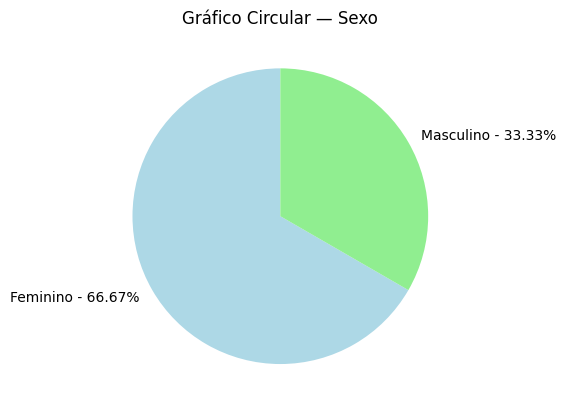

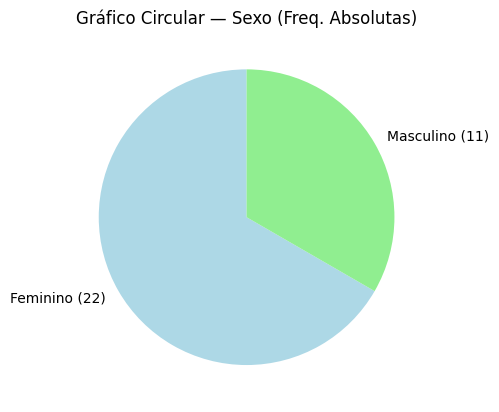

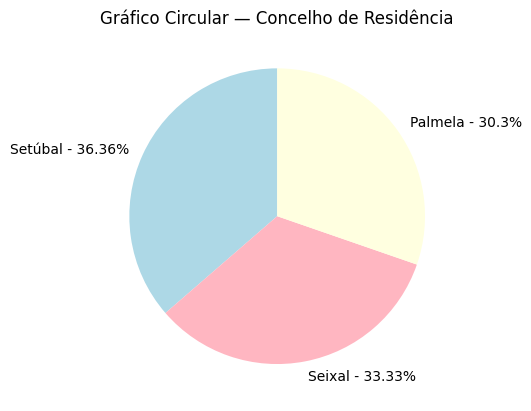

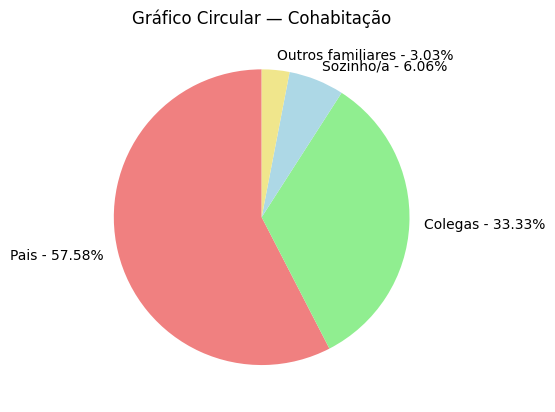

In [ ]:
# 🔧 Função genérica para gerar gráfico circular
# ==========================================================
def pie_var(df, col, percent=True, cores=None, titulo=None):
    """
    Gera um gráfico circular para uma variável categórica.

    Parâmetros:
        df : DataFrame pandas
        col : str — nome da coluna categórica
        percent : bool — se True mostra percentagens, senão frequências absolutas
        cores : list — lista de cores (opcional)
        titulo : str — título do gráfico (opcional)
    """
    if percent:
        # Frequências relativas (%)
        freq = (df[col].value_counts(normalize=True) * 100).round(2)
        rotulos = [f"{cat} - {val}%" for cat, val in zip(freq.index, freq.values)]
    else:
        # Frequências absolutas
        freq = df[col].value_counts()
        rotulos = [f"{cat} ({val})" for cat, val in zip(freq.index, freq.values)]

    # Gráfico circular
    plt.pie(freq, labels=rotulos, colors=cores, startangle=90, autopct=None)
    plt.title(titulo or f"Gráfico Circular — {col}")
    plt.show()


# ==========================================================
# 🔹 Exemplos com o teu dataset df
# ==========================================================

# 1️⃣ Sexo — gráfico simples
pie_var(
    df,
    'Sexo',
    percent=True,
    cores=['lightblue', 'lightgreen'],
    titulo='Gráfico Circular — Sexo'
)

# 2️⃣ Sexo — com frequências absolutas
pie_var(
    df,
    'Sexo',
    percent=False,
    cores=['lightblue', 'lightgreen'],
    titulo='Gráfico Circular — Sexo (Freq. Absolutas)'
)

# 3️⃣ Residência — percentagens
pie_var(
    df,
    'Residencia',
    percent=True,
    cores=['lightblue', 'lightpink', 'lightyellow'],
    titulo='Gráfico Circular — Concelho de Residência'
)

# 4️⃣ Cohabitação — percentagens com 4 cores
pie_var(
    df,
    'Cohabitação',
    percent=True,
    cores=['lightcoral', 'lightgreen', 'lightblue', 'khaki'],
    titulo='Gráfico Circular — Cohabitação'
)

# ==========================================================
# 🧠 Notas:
# - Usa percent=True para percentagens (prop.table no R)
# - Usa percent=False para frequências absolutas (table no R)
# - Parâmetro cores aceita nomes CSS, hex ou None (default)
# - startangle=90 apenas roda o gráfico para melhor leitura
# ==========================================================

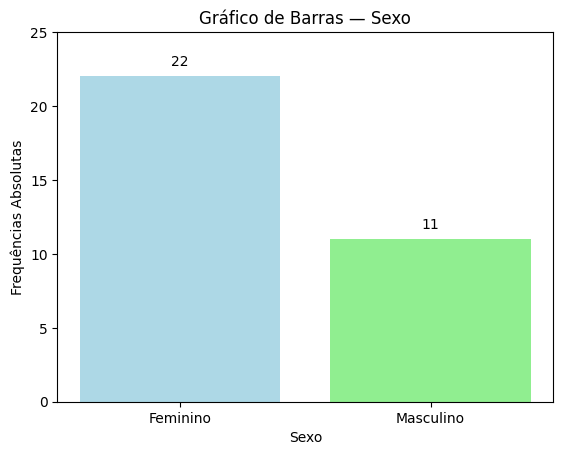

In [ ]:
# Frequências absolutas
freq = df['Sexo'].value_counts()

plt.bar(freq.index, freq.values, color=['lightblue', 'lightgreen'])
plt.title('Gráfico de Barras — Sexo')
plt.xlabel('Sexo')
plt.ylabel('Frequências Absolutas')
plt.ylim(0, 25)

# Adicionar valores por cima das barras
for i, val in enumerate(freq.values):
    plt.text(i, val + 0.5, str(val), ha='center', va='bottom')

plt.show()

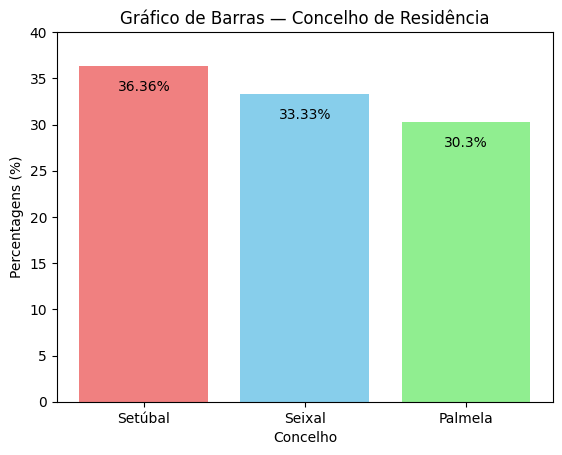

In [ ]:
# Frequências relativas em percentagem
freq_pct = (df['Residencia'].value_counts(normalize=True) * 100).round(2)

plt.bar(freq_pct.index, freq_pct.values, color=['lightcoral', 'skyblue', 'lightgreen'])
plt.title('Gráfico de Barras — Concelho de Residência')
plt.xlabel('Concelho')
plt.ylabel('Percentagens (%)')
plt.ylim(0, 40)

# Valores no interior das barras
for i, val in enumerate(freq_pct.values):
    plt.text(i, val - 3, f'{val}%', ha='center', va='bottom', color='black')

plt.show()

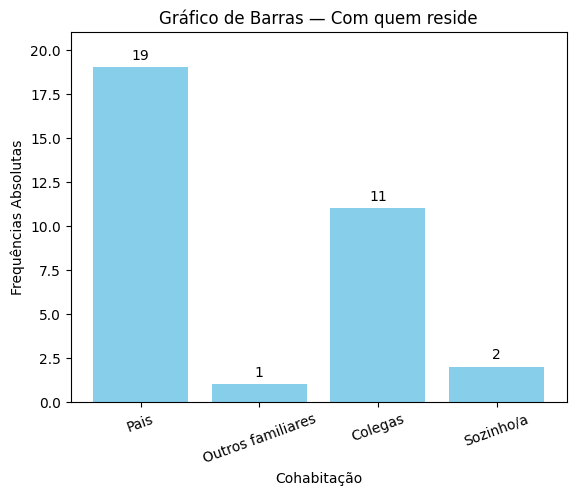

In [ ]:
freq_cohab = df['Cohabitação'].value_counts().reindex(
    ['Pais', 'Outros familiares', 'Colegas', 'Sozinho/a']
)

plt.bar(freq_cohab.index, freq_cohab.values, color='skyblue')
plt.title('Gráfico de Barras — Com quem reside')
plt.xlabel('Cohabitação')
plt.ylabel('Frequências Absolutas')
plt.ylim(0, 21)

# Labels acima das barras
for i, val in enumerate(freq_cohab.values):
    plt.text(i, val + 0.3, str(val), ha='center', va='bottom')

plt.xticks(rotation=20)
plt.show()


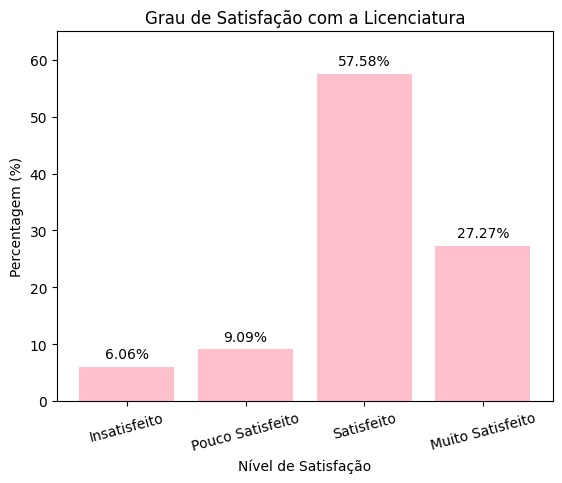

In [ ]:
freq_sat = (df['SatisfaçãoLic'].value_counts(normalize=True) * 100).round(2)
freq_sat = freq_sat.reindex(['Insatisfeito', 'Pouco Satisfeito', 'Satisfeito', 'Muito Satisfeito'])

plt.bar(freq_sat.index, freq_sat.values, color='pink')
plt.title('Grau de Satisfação com a Licenciatura')
plt.xlabel('Nível de Satisfação')
plt.ylabel('Percentagem (%)')
plt.ylim(0, 65)

# Percentagens por cima das barras
for i, val in enumerate(freq_sat.values):
    plt.text(i, val + 1, f'{val}%', ha='center', va='bottom')

plt.xticks(rotation=15)
plt.show()


In [ ]:
# 🔹 1️⃣ Idade — variável discreta
print("📊 Frequências absolutas — Idade")
print(df['Idade'].value_counts().sort_index())

print("\n📊 Frequências relativas (%) — Idade")
print((df['Idade'].value_counts(normalize=True).sort_index() * 100).round(2))

# 🔹 2️⃣ Deslocação — também discreta
print("\n📊 Frequências absolutas — Deslocação")
print(df['Deslocação'].value_counts().sort_index())

print("\n📊 Frequências relativas (%) — Deslocação")
print((df['Deslocação'].value_counts(normalize=True).sort_index() * 100).round(2))

# 🔹 3️⃣ Altura — variável contínua (muitos valores)
print("\n📊 Frequências absolutas — Altura (apenas para referência)")
print(df['Altura'].value_counts().sort_index())

print("\n📊 Frequências relativas (%) — Altura")
print((df['Altura'].value_counts(normalize=True).sort_index() * 100).round(2))

# 🔹 4️⃣ Peso — também contínua
print("\n📊 Frequências absolutas — Peso (apenas para referência)")
print(df['Peso'].value_counts().sort_index())

print("\n📊 Frequências relativas (%) — Peso")
print((df['Peso'].value_counts(normalize=True).sort_index() * 100).round(2))

📊 Frequências absolutas — Idade
Idade
20    14
21    14
22     1
23     2
24     1
28     1
Name: count, dtype: int64

📊 Frequências relativas (%) — Idade
Idade
20    42.42
21    42.42
22     3.03
23     6.06
24     3.03
28     3.03
Name: proportion, dtype: float64

📊 Frequências absolutas — Deslocação
Deslocação
10     1
15     3
20     5
22     1
25     2
30     6
40     1
45     2
50     1
60     2
90     3
120    3
140    1
160    2
Name: count, dtype: int64

📊 Frequências relativas (%) — Deslocação
Deslocação
10      3.03
15      9.09
20     15.15
22      3.03
25      6.06
30     18.18
40      3.03
45      6.06
50      3.03
60      6.06
90      9.09
120     9.09
140     3.03
160     6.06
Name: proportion, dtype: float64

📊 Frequências absolutas — Altura (apenas para referência)
Altura
150    1
154    1
155    1
158    1
160    3
161    3
163    1
164    2
165    5
168    1
170    3
172    2
174    1
175    1
178    4
182    1
183    1
185    1
Name: count, dtype: int64

📊 Frequênc

In [ ]:
def tabela_classes(df, coluna, n_classes):
    # Criar intervalos (classes)
    categorias = pd.cut(df[coluna], bins=n_classes, include_lowest=True)

    # Frequências absolutas
    freq_abs = categorias.value_counts().sort_index()

    # Frequências relativas (%)
    freq_rel = (freq_abs / freq_abs.sum() * 100).round(2)

    # Juntar tudo num DataFrame bonito
    tabela = pd.DataFrame({
        "Intervalo": freq_abs.index.astype(str),
        "Frequência Absoluta": freq_abs.values,
        "Frequência Relativa (%)": freq_rel.values
    })

    return tabela


# 🔹 1️⃣ Deslocação — 3 classes
tabela_desloc_3 = tabela_classes(df, 'Deslocação', 3)
print("📊 Deslocação (3 classes)")
print(tabela_desloc_3, "\n")

# 🔹 2️⃣ Deslocação — 4 classes
tabela_desloc_4 = tabela_classes(df, 'Deslocação', 4)
print("📊 Deslocação (4 classes)")
print(tabela_desloc_4, "\n")

# 🔹 3️⃣ Altura — 4 classes
tabela_altura = tabela_classes(df, 'Altura', 4)
print("📊 Altura (4 classes)")
print(tabela_altura, "\n")

# 🔹 4️⃣ Peso — 5 classes
tabela_peso = tabela_classes(df, 'Peso', 5)
print("📊 Peso (5 classes)")
print(tabela_peso, "\n")

📊 Deslocação (3 classes)
        Intervalo  Frequência Absoluta  Frequência Relativa (%)
0   (9.849, 60.0]                   24                    72.73
1   (60.0, 110.0]                    3                     9.09
2  (110.0, 160.0]                    6                    18.18 

📊 Deslocação (4 classes)
        Intervalo  Frequência Absoluta  Frequência Relativa (%)
0   (9.849, 47.5]                   21                    63.64
1    (47.5, 85.0]                    3                     9.09
2   (85.0, 122.5]                    6                    18.18
3  (122.5, 160.0]                    3                     9.09 

📊 Altura (4 classes)
           Intervalo  Frequência Absoluta  Frequência Relativa (%)
0  (149.964, 158.75]                    4                    12.12
1    (158.75, 167.5]                   14                    42.42
2    (167.5, 176.25]                    8                    24.24
3    (176.25, 185.0]                    7                    21.21 

📊 Peso (5 cl

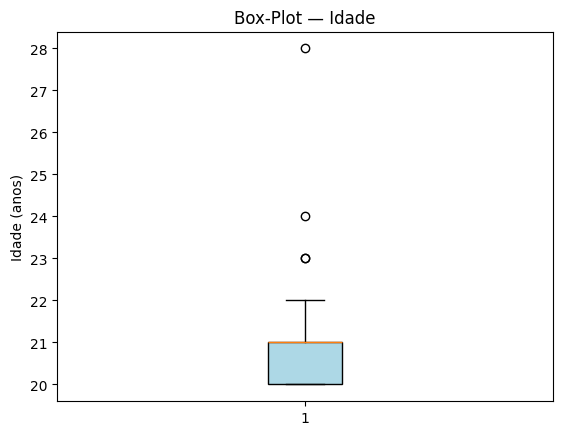

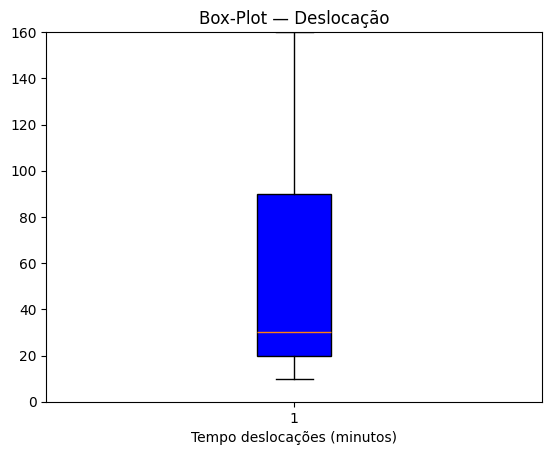

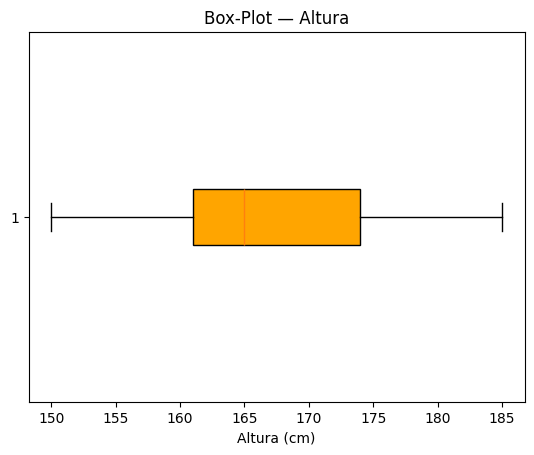

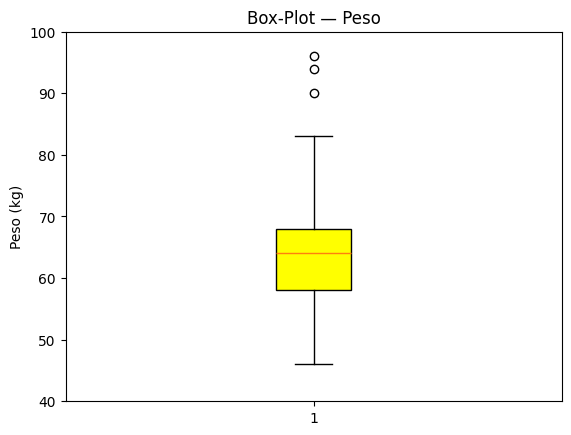

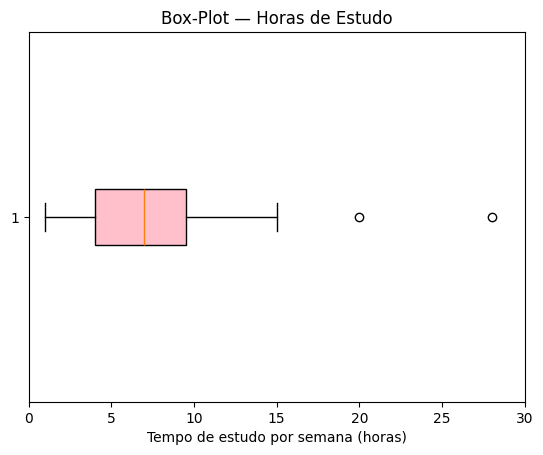

In [ ]:
# 🔹 Idade
plt.boxplot(df['Idade'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title("Box-Plot — Idade")
plt.ylabel("Idade (anos)")
plt.show()

# 🔹 Deslocação
plt.boxplot(df['Deslocação'], patch_artist=True, boxprops=dict(facecolor='blue'))
plt.title("Box-Plot — Deslocação")
plt.xlabel("Tempo deslocações (minutos)")
plt.ylim(0, 160)
plt.show()

# 🔹 Altura (horizontal)
plt.boxplot(df['Altura'], vert=False, patch_artist=True, boxprops=dict(facecolor='orange'))
plt.title("Box-Plot — Altura")
plt.xlabel("Altura (cm)")
plt.show()

# 🔹 Peso
plt.boxplot(df['Peso'], patch_artist=True, boxprops=dict(facecolor='yellow'))
plt.title("Box-Plot — Peso")
plt.ylabel("Peso (kg)")
plt.ylim(40, 100)
plt.show()

# 🔹 Horas de Estudo (horizontal)
plt.boxplot(df['HorasEstudo'], vert=False, patch_artist=True, boxprops=dict(facecolor='pink'))
plt.title("Box-Plot — Horas de Estudo")
plt.xlabel("Tempo de estudo por semana (horas)")
plt.xlim(0, 30)
plt.show()

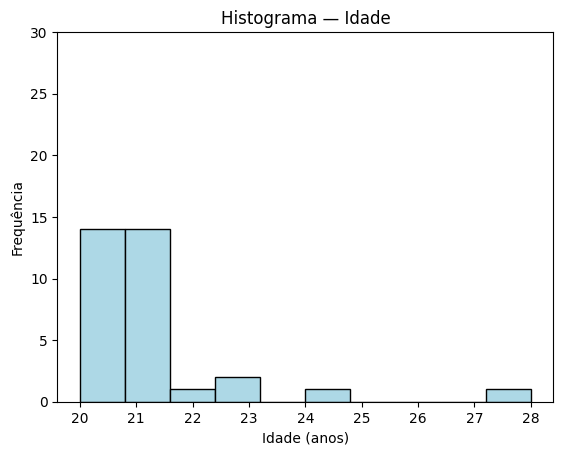

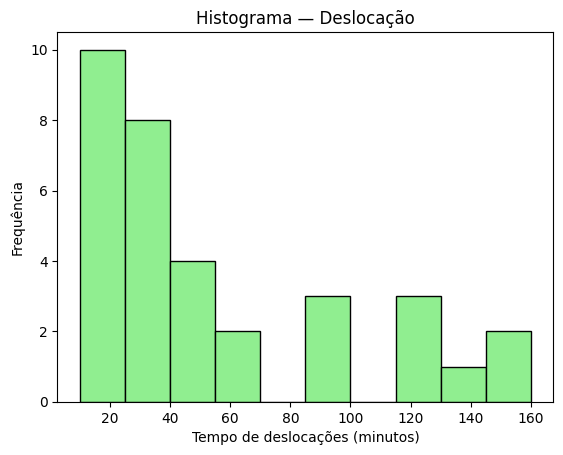

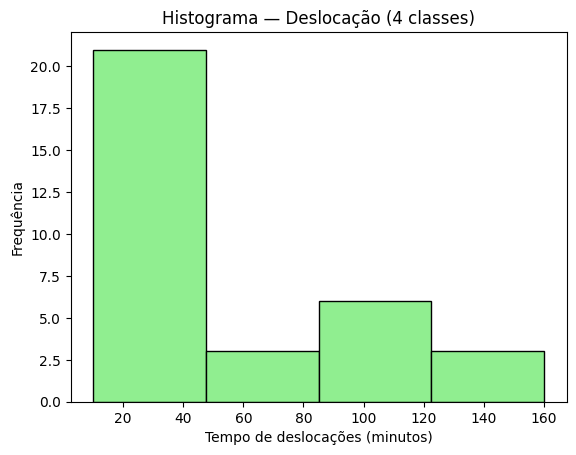

In [ ]:
# 🔹 Idade
plt.hist(df['Idade'], color='lightblue', edgecolor='black')
plt.title("Histograma — Idade")
plt.xlabel("Idade (anos)")
plt.ylabel("Frequência")
plt.ylim(0, 30)
plt.show()

# 🔹 Deslocação (default bins)
plt.hist(df['Deslocação'], color='lightgreen', edgecolor='black')
plt.title("Histograma — Deslocação")
plt.xlabel("Tempo de deslocações (minutos)")
plt.ylabel("Frequência")
plt.show()

# 🔹 Deslocação (com número de intervalos = 4 → breaks=4 no R)
plt.hist(df['Deslocação'], bins=4, color='lightgreen', edgecolor='black')
plt.title("Histograma — Deslocação (4 classes)")
plt.xlabel("Tempo de deslocações (minutos)")
plt.ylabel("Frequência")
plt.show()